In [14]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import ParameterGrid

# ⚙️ CONFIG – Sửa đường dẫn file của bạn ở đây
CSV_PATH = r"feature_for_clustering1.csv"

COLS_TO_DROP = ["CREATOR_ID",'FOLLOWING_COUNT', 'HAS_BROADCAST_SCORE','VIRAL_MAGNITUDE','ENGAGEMENT',  'VIEW_MEAN_V',]

USE_PCA = True
PCA_VARIANCE = 0.95
RANDOM_STATE = 42

In [15]:
# 1. Đọc dữ liệu
df = pd.read_csv(CSV_PATH)
print(f"Dữ liệu gốc: {df.shape[0]} dòng, {df.shape[1]} cột")
print(df.shape)
print(df.columns.tolist())
df.describe(percentiles=[0.5, 0.9, 0.99]).T

Dữ liệu gốc: 2845 dòng, 28 cột
(2845, 28)
['CREATOR_ID', 'VIEW_P90', 'MAX_VIEWS_3M', 'FOLLOWERS', 'VIDEO_COUNT', 'VIDEO_COUNT_3M_x', 'VIEW_STD', 'VIEW_CV', 'VIEW_MEAN_V', 'MEAN_LIKES_3M', 'MAX_LIKES_3M', 'MEAN_COMMENTS_3M', 'MAX_COMMENTS_3M', 'MEAN_SHARES_3M', 'MAX_SHARES_3M', 'MEAN_SAVES_3M', 'MAX_SAVES_3M', 'MEAN_VIEWS_RATE_3M', 'MEAN_LIKE_RATE_3M', 'MEAN_COMMENT_RATE_3M', 'MEAN_SHARE_RATE_3M', 'MEAN_SAVE_RATE_3M', 'AVG_POST_GAP', 'POSTING_CONSISTENCY', 'VIDEOS_PER_WEEK', 'MAX_VIRAL_STRENGTH', 'COLLAB_SCORE', 'VIRAL_MAGNITUDE']


,count,mean,std,min,50%,90%,99%,max
VIEW_P90,2845.0,5.028613e+05,1.161938e+06,439.000000,179460.000000,1.200000e+06,4.100000e+06,3.524000e+07
MAX_VIEWS_3M,2845.0,2.459418e+06,4.900270e+06,462.000000,945700.000000,5.900000e+06,2.261200e+07,6.860000e+07
FOLLOWERS,2845.0,4.321473e+05,1.126489e+06,4864.000000,149900.000000,9.286200e+05,4.636000e+06,2.120000e+07
VIDEO_COUNT,2845.0,7.195508e+02,1.395749e+03,1.000000,374.000000,1.489600e+03,6.142320e+03,3.590000e+04
VIDEO_COUNT_3M_x,2845.0,7.242777e+01,9.731132e+01,1.000000,39.000000,1.750000e+02,5.140000e+02,5.600000e+02
VIEW_STD,2845.0,4.281103e+05,8.406771e+05,0.000000,173222.443259,9.959919e+05,3.731535e+06,1.411421e+07
VIEW_CV,2845.0,1.906742e+00,1.231057e+00,0.000000,1.647723,3.375784e+00,6.304362e+00,1.484748e+01
VIEW_MEAN_V,2845.0,2.417220e+05,6.021235e+05,205.741379,101964.442105,5.703512e+05,1.987390e+06,2.037500e+07
MEAN_LIKES_3M,2845.0,9.371296e+03,2.383030e+04,1.500000,3254.742857,2.181409e+04,8.733122e+04,8.419000e+05
MAX_LIKES_3M,2845.0,8.813662e+04,1.849988e+05,8.000000,30900.000000,2.170200e+05,7.829360e+05,3.600000e+06


In [16]:
df =df.drop(columns='CREATOR_ID')

In [17]:

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

In [18]:
print(f"Dữ liệu sau scale: {X_scaled.shape[0]} dòng, {X_scaled.shape[1]} cột")
print(X_scaled.columns.tolist())
X_scaled.describe(percentiles=[0.5, 0.9, 0.99]).T

Dữ liệu sau scale: 2845 dòng, 27 cột
['VIEW_P90', 'MAX_VIEWS_3M', 'FOLLOWERS', 'VIDEO_COUNT', 'VIDEO_COUNT_3M_x', 'VIEW_STD', 'VIEW_CV', 'VIEW_MEAN_V', 'MEAN_LIKES_3M', 'MAX_LIKES_3M', 'MEAN_COMMENTS_3M', 'MAX_COMMENTS_3M', 'MEAN_SHARES_3M', 'MAX_SHARES_3M', 'MEAN_SAVES_3M', 'MAX_SAVES_3M', 'MEAN_VIEWS_RATE_3M', 'MEAN_LIKE_RATE_3M', 'MEAN_COMMENT_RATE_3M', 'MEAN_SHARE_RATE_3M', 'MEAN_SAVE_RATE_3M', 'AVG_POST_GAP', 'POSTING_CONSISTENCY', 'VIDEOS_PER_WEEK', 'MAX_VIRAL_STRENGTH', 'COLLAB_SCORE', 'VIRAL_MAGNITUDE']


,count,mean,std,min,50%,90%,99%,max
VIEW_P90,2845.0,6.493536e-17,1.000176,-0.432476,-0.278378,0.600085,3.096355,29.901130
MAX_VIEWS_3M,2845.0,6.243785e-18,1.000176,-0.501888,-0.308959,0.702244,4.113268,13.499708
FOLLOWERS,2845.0,1.748260e-17,1.000176,-0.379372,-0.250599,0.440803,3.732475,18.439154
VIDEO_COUNT,2845.0,-1.123881e-17,1.000176,-0.514904,-0.247617,0.551807,3.885886,25.209855
VIDEO_COUNT_3M_x,2845.0,9.990056e-18,1.000176,-0.734142,-0.343574,1.054248,4.538525,5.011318
VIEW_STD,2845.0,1.123881e-17,1.000176,-0.509334,-0.303247,0.675624,3.930172,16.282720
VIEW_CV,2845.0,1.748260e-17,1.000176,-1.549138,-0.210440,1.193528,3.572861,10.513741
VIEW_MEAN_V,2845.0,8.741299e-18,1.000176,-0.401178,-0.232149,0.545880,2.899696,33.443001
MEAN_LIKES_3M,2845.0,-2.185325e-17,1.000176,-0.393257,-0.256716,0.522233,3.272037,34.941862
MAX_LIKES_3M,2845.0,-2.497514e-17,1.000176,-0.476458,-0.309444,0.696794,3.756357,18.986507


In [19]:
# 4. Giảm chiều PCA (Tùy chọn)
if USE_PCA and X_scaled.shape[1] > 2:
    pca = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)
    X_ready = pca.fit_transform(X_scaled)
    print(f"Đã dùng PCA giảm từ {X_scaled.shape[1]} xuống {X_ready.shape[1]} chiều.")
else:
    X_ready = X_scaled
    print("Không sử dụng PCA.")

print(f"Shape dữ liệu sẵn sàng train: {X_ready.shape}")

Đã dùng PCA giảm từ 27 xuống 18 chiều.
Shape dữ liệu sẵn sàng train: (2845, 18)


In [20]:
X_ready

array([[-1.41745362, -0.78341233,  0.30859404, ...,  0.09579749,
         0.24573221,  0.08801597],
       [-0.79348631,  3.3569807 ,  0.33586873, ..., -0.3450772 ,
         0.18030069,  0.25188378],
       [-0.08490426,  4.05674692,  0.46026324, ..., -0.5935951 ,
         0.29748811,  0.078924  ],
       ...,
       [-0.92754359, -0.83732919, -0.56680015, ...,  0.62586411,
        -0.11562401,  0.47319612],
       [-0.02372535,  1.7667867 ,  0.14959034, ..., -0.0928537 ,
        -0.24632951, -0.10943555],
       [-1.49246324, -1.23218075,  0.08823473, ...,  0.00686363,
         0.00997516,  0.00864716]])

In [21]:
# Khai báo các class model tương ứng
MODEL_CLASSES = {
    "KMeans": KMeans,
    "Hierarchical": AgglomerativeClustering,
    "DBSCAN": DBSCAN,
    "GMM": GaussianMixture,
    "BIRCH": Birch,
    # "Spectral": SpectralClustering
}

# Khai báo lưới tham số cần tune
PARAM_GRIDS = {
    "KMeans": {
        "n_clusters": [2, 3, 4, 5, 6],
        "init": ["k-means++", "random"],
        "n_init": [10],
        "random_state": [RANDOM_STATE]
    },
    "Hierarchical": {
        "n_clusters": [2, 3, 4, 5, 6],
        "linkage": ["ward", "complete", "average"]
    },
    "DBSCAN": {
        "eps": [0.3, 0.5, 0.7, 1.0],
        "min_samples": [3, 5, 10]
    },
    "GMM": {
        "n_components": [2, 3, 4, 5, 6],
        "covariance_type": ["full", "tied", "diag"],
        "random_state": [RANDOM_STATE]
    },
    "BIRCH": {
        "threshold": [0.3, 0.5],
        "n_clusters": [2, 3, 4, 5, 6]
    # },
    #     "Spectral": {
    #     "n_clusters": [2],
    #     "affinity": ["rbf"],
    #     "assign_labels": ["kmeans"],
    }
#     "Spectral": {
#     "n_clusters": [2, 3, 4, 5],
#     "affinity": ["rbf", "nearest_neighbors"],
#     "gamma": [0.1, 0.5, 1],
#     "n_neighbors": [5, 10, 15],
#     "assign_labels": ["kmeans", "discretize"],
# }
}

Hàm huấn luyện và đánh giá cốt lõi

In [22]:
def get_metrics(X, labels):
    """Tính toán Silhouette và Davies-Bouldin, bỏ qua nhiễu (label -1)"""
    unique_labels = set(labels) - {-1}
    n_clusters = len(unique_labels)
    valid_mask = labels != -1
    
    if n_clusters < 2 or valid_mask.sum() < n_clusters + 1:
        return np.nan, np.nan, n_clusters
        
    X_valid, labels_valid = X[valid_mask], labels[valid_mask]
    
    sil = silhouette_score(X_valid, labels_valid)
    db = davies_bouldin_score(X_valid, labels_valid)
    return round(sil, 4), round(db, 4), n_clusters

def run_tuning_pipeline(X, model_classes, param_grids):
    """Chạy toàn bộ quá trình tuning và trả về list kết quả"""
    results = []
    
    for model_name, grid in param_grids.items():
        print(f"Đang chạy {model_name}...")
        model_class = model_classes[model_name]
        
        for params in ParameterGrid(grid):
            try:
                # Khởi tạo và fit model
                model = model_class(**params)
                
                if model_name == "GMM":
                    model.fit(X)
                    labels = model.predict(X)
                else:
                    labels = model.fit_predict(X)
                
                # Tính điểm
                sil, db, n_clusters = get_metrics(X, labels)
                
                # Lưu kết quả
                row = {"model": model_name, "n_clusters_found": n_clusters, **params, 
                       "silhouette": sil, "davies_bouldin": db}
                results.append(row)
                
            except Exception as e:
                # Bỏ qua im lặng các model lỗi tham số để không đứt pipeline
                pass 
                
    return pd.DataFrame(results)

Param grids

In [23]:
# 1. Chạy tuning
df_results = run_tuning_pipeline(X_ready, MODEL_CLASSES, PARAM_GRIDS)

# 2. Xóa các dòng không tính được điểm (n_clusters < 2)
df_valid = df_results.dropna(subset=["silhouette", "davies_bouldin"]).copy()

# 3. Tính Composite Score (Min-Max Normalize thẳng trên Pandas)
if not df_valid.empty:
    sil_norm = (df_valid["silhouette"] - df_valid["silhouette"].min()) / (df_valid["silhouette"].max() - df_valid["silhouette"].min() + 1e-9)
    # DBI càng thấp càng tốt nên lấy 1 trừ đi
    db_inv_norm = 1 - ((df_valid["davies_bouldin"] - df_valid["davies_bouldin"].min()) / (df_valid["davies_bouldin"].max() - df_valid["davies_bouldin"].min() + 1e-9))
    
    df_valid["composite_score"] = round(0.5 * sil_norm + 0.5 * db_inv_norm, 4)
    
    # 4. Tìm ra model tốt nhất cho mỗi thuật toán
    best_models = df_valid.loc[df_valid.groupby('model')['composite_score'].idxmax()]
    best_models = best_models.sort_values(by="composite_score", ascending=False).reset_index(drop=True)
    
    print("\n🏆 TOP CÁC MODEL TỐT NHẤT TỪNG THUẬT TOÁN:")
    display(best_models[["model", "n_clusters_found", "silhouette", "davies_bouldin", "composite_score"]])
else:
    print("Không có thuật toán nào phân cụm thành công (>1 cụm).")

Đang chạy KMeans...
Đang chạy Hierarchical...
Đang chạy DBSCAN...
Đang chạy GMM...
Đang chạy BIRCH...

🏆 TOP CÁC MODEL TỐT NHẤT TỪNG THUẬT TOÁN:


,model,n_clusters_found,silhouette,davies_bouldin,composite_score
0,Hierarchical,4,0.8967,0.0643,0.9947
1,GMM,2,0.6540,1.6322,0.6545
2,KMeans,2,0.6182,1.5286,0.6533
3,DBSCAN,20,0.3749,0.8082,0.6478
4,BIRCH,6,0.4304,1.2347,0.6107


In [24]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
display(best_models)

,model,n_clusters_found,init,n_clusters,n_init,random_state,silhouette,davies_bouldin,linkage,eps,min_samples,covariance_type,n_components,threshold,composite_score
0,Hierarchical,4,NaN,4.0,NaN,NaN,0.8967,0.0643,average,NaN,NaN,NaN,NaN,NaN,0.9947
1,GMM,2,NaN,NaN,NaN,42.0,0.6540,1.6322,NaN,NaN,NaN,tied,2.0,NaN,0.6545
2,KMeans,2,k-means++,2.0,10.0,42.0,0.6182,1.5286,NaN,NaN,NaN,NaN,NaN,NaN,0.6533
3,DBSCAN,20,NaN,NaN,NaN,NaN,0.3749,0.8082,NaN,0.5,3.0,NaN,NaN,NaN,0.6478
4,BIRCH,6,NaN,6.0,NaN,NaN,0.4304,1.2347,NaN,NaN,NaN,NaN,NaN,0.5,0.6107


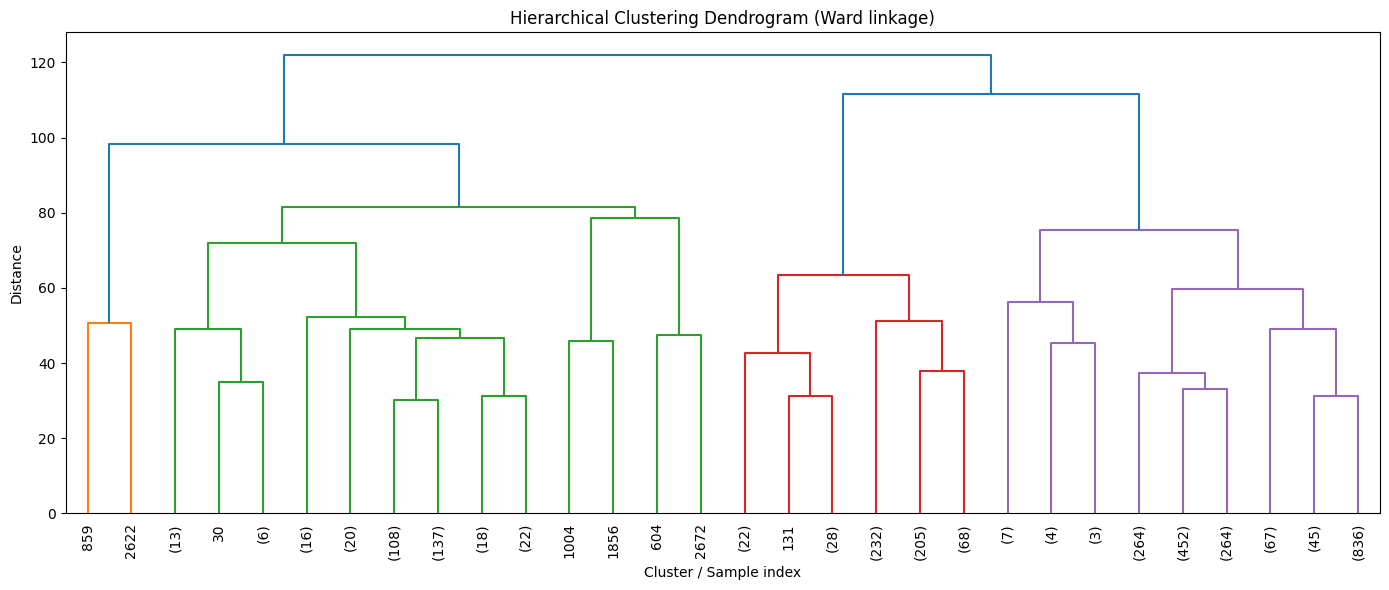

KeyboardInterrupt: 

In [25]:
from scipy.cluster.hierarchy import linkage, dendrogram
from collections import Counter
# ------------------------------------------------------------
# 2.3. HIERARCHICAL CLUSTERING: Dendrogram + huấn luyện
# ------------------------------------------------------------
def plot_dendrogram_and_choose_k(X, truncate_mode="lastp", p=30):
    """
    Vẽ dendrogram để người dùng quan sát trực quan.
    Đồng thời gợi ý số cụm bằng cách xét các khoảng nhảy lớn trong linkage distance.

    Returns
    -------
    Z : linkage matrix
    suggested_k : int
    """
    Z = linkage(X, method="ward")

    plt.figure(figsize=(14, 6))
    dendrogram(Z, truncate_mode=truncate_mode, p=p, leaf_rotation=90, leaf_font_size=10)
    plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
    plt.xlabel("Cluster / Sample index")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

    # heuristic: tìm khoảng nhảy lớn trong các khoảng cách hợp nhất cuối
    merge_distances = Z[:, 2]
    last_distances = merge_distances[-10:] if len(merge_distances) >= 10 else merge_distances
    diffs = np.diff(last_distances)

    if len(diffs) > 0:
        jump_idx = np.argmax(diffs)
        # số cụm xấp xỉ: số merge cuối còn lại trước cú nhảy
        suggested_k = max(2, len(last_distances) - jump_idx)
    else:
        suggested_k = 3

    return Z, suggested_k


Z, suggested_k_hier = plot_dendrogram_and_choose_k(X_ready, truncate_mode="lastp", p=30)

agglomerative = AgglomerativeClustering(n_clusters=2, linkage="ward")
hier_labels = agglomerative.fit_predict(X_ready)

print("\nHierarchical suggested K:", suggested_k_hier)
print("Hierarchical cluster counts:", Counter(hier_labels))

## Phân tích